In [ ]:
!pip install -q python-dotenv transformers datasets scikit-learn torch gensim sentencepiece

import os
import sys
import gc
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from dotenv import load_dotenv
from transformers import AutoTokenizer, BertForSequenceClassification, TrainingArguments
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score

from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/NLP'
if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)
os.chdir(PROJECT_PATH)


from data.data_processor import DataProcessor
from data.dataset import FoodDataset
from models.dual_trainer import DualModelTrainer
from evaluation.post_processor import ModelPostProcessor
from evaluation.create_confusion_matrix import ConfusionMatrixCreator

load_dotenv(os.path.join(PROJECT_PATH, '.env'))
hf_token = os.getenv('HF_TOKEN')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Χρήση συσκευής: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 31.7 MB/s eta 0:00:00
Mounted at /content/drive
Χρήση συσκευής: cuda


In [ ]:
processor = DataProcessor()
data = processor.process_data(
    train_path='csv/train.csv',
    val_path='csv/valid.csv',
    test_path='csv/test.csv',
    tokenize=False
)

train_df = data['train_df']
val_df   = data['val_df']
test_df  = data['test_df']

hazard_weights = compute_class_weight('balanced', classes=np.unique(train_df['hazard_label']), y=train_df['hazard_label'].values)
product_weights = compute_class_weight('balanced', classes=np.unique(train_df['product_label']), y=train_df['product_label'].values)

tensor_hazard_weights = torch.tensor(hazard_weights, dtype=torch.float32).to(device)
tensor_product_weights = torch.tensor(product_weights, dtype=torch.float32).to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"macro_f1": f1_score(labels, predictions, average='macro')}

LOCAL_TEMP_DIR = "/content/temp_models"
os.makedirs(LOCAL_TEMP_DIR, exist_ok=True)

In [ ]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_dataset = FoodDataset(train_df['clean_text'], train_df['hazard_label'], train_df['product_label'], tokenizer)
val_dataset = FoodDataset(val_df['clean_text'], val_df['hazard_label'], val_df['product_label'], tokenizer)

dummy_test_labels = pd.Series([0] * len(test_df))
test_dataset = FoodDataset(test_df['clean_text'], dummy_test_labels, dummy_test_labels, tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
#HAZARD
model_hazard = BertForSequenceClassification.from_pretrained(model_name, num_labels=10).to(device)

args_hazard = TrainingArguments(
    output_dir=f"{LOCAL_TEMP_DIR}/res_bert_haz", eval_strategy="epoch", save_strategy="epoch",
    learning_rate=2e-5, per_device_train_batch_size=16, per_device_eval_batch_size=16,
    num_train_epochs=15, load_best_model_at_end=True, metric_for_best_model="macro_f1",
    remove_unused_columns=False, label_names=['hazard_label'], save_total_limit=1
)

trainer_hazard = DualModelTrainer(
    target_column='hazard_label', class_weights=tensor_hazard_weights,
    model=model_hazard, args=args_hazard,
    train_dataset=train_dataset, eval_dataset=val_dataset, compute_metrics=compute_metrics
)
trainer_hazard.train()

bert_hazard_test_probs = F.softmax(torch.tensor(trainer_hazard.predict(test_dataset).predictions), dim=-1).numpy()
bert_hazard_val_probs = F.softmax(torch.tensor(trainer_hazard.predict(val_dataset).predictions), dim=-1).numpy()

preds_hazard_test = np.argmax(bert_hazard_test_probs, axis=-1)
preds_hazard_val = np.argmax(bert_hazard_val_probs, axis=-1)

del model_hazard, trainer_hazard
torch.cuda.empty_cache()
gc.collect()

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1
1,No log,0.993682,0.652558
2,1.267896,0.703447,0.692593
3,1.267896,0.713740,0.826109
4,0.495545,0.789725,0.802370
5,0.262085,0.775012,0.837393
6,0.262085,0.808824,0.874553
7,0.156740,0.856010,0.848084
8,0.099393,0.883217,0.855615
9,0.099393,0.925255,0.830589
10,0.063927,1.065117,0.847136


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

577

In [ ]:
#PRODUCT
model_product = BertForSequenceClassification.from_pretrained(model_name, num_labels=22).to(device)

args_product = TrainingArguments(
    output_dir=f"{LOCAL_TEMP_DIR}/res_bert_prod", eval_strategy="epoch", save_strategy="epoch",
    learning_rate=2e-5, per_device_train_batch_size=16, per_device_eval_batch_size=16,
    num_train_epochs=15, load_best_model_at_end=True, metric_for_best_model="macro_f1",
    remove_unused_columns=False, label_names=['product_label'], save_total_limit=1
)

trainer_product = DualModelTrainer(
    target_column='product_label', class_weights=tensor_product_weights,
    model=model_product, args=args_product,
    train_dataset=train_dataset, eval_dataset=val_dataset, compute_metrics=compute_metrics
)
trainer_product.train()

bert_product_test_probs = F.softmax(torch.tensor(trainer_product.predict(test_dataset).predictions), dim=-1).numpy()
bert_product_val_probs = F.softmax(torch.tensor(trainer_product.predict(val_dataset).predictions), dim=-1).numpy()

preds_product_test = np.argmax(bert_product_test_probs, axis=-1)
preds_product_val = np.argmax(bert_product_val_probs, axis=-1)

del model_product, trainer_product
torch.cuda.empty_cache()
gc.collect()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1
1,No log,1.697524,0.541381
2,2.205828,1.212181,0.613362
3,2.205828,1.039978,0.657454
4,1.046919,1.068589,0.677526
5,0.577176,1.038276,0.707568
6,0.577176,1.082064,0.770968
7,0.356080,1.224066,0.697471
8,0.200312,1.279505,0.774948
9,0.200312,1.383517,0.769924
10,0.118048,1.444119,0.771501


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

568

In [ ]:
post_processor = ModelPostProcessor(
    model_prefix="bert",
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    data_dict=data
)

post_processor.save_probabilities(
    haz_val_probs=bert_hazard_val_probs,
    haz_test_probs=bert_hazard_test_probs,
    prod_val_probs=bert_product_val_probs,
    prod_test_probs=bert_product_test_probs
)

post_processor.evaluate_and_export(
    preds_haz_val=preds_hazard_val,
    preds_prod_val=preds_product_val,
    preds_haz_test=preds_hazard_test,
    preds_prod_test=preds_product_test
)

ST1 SCORE (Validation): 0.7691
Hazard F1: 0.8746 | Product F1: 0.6637
Το αρχείο 'csv/bert_submission.csv' δημιουργήθηκε επιτυχώς (997 γραμμές).


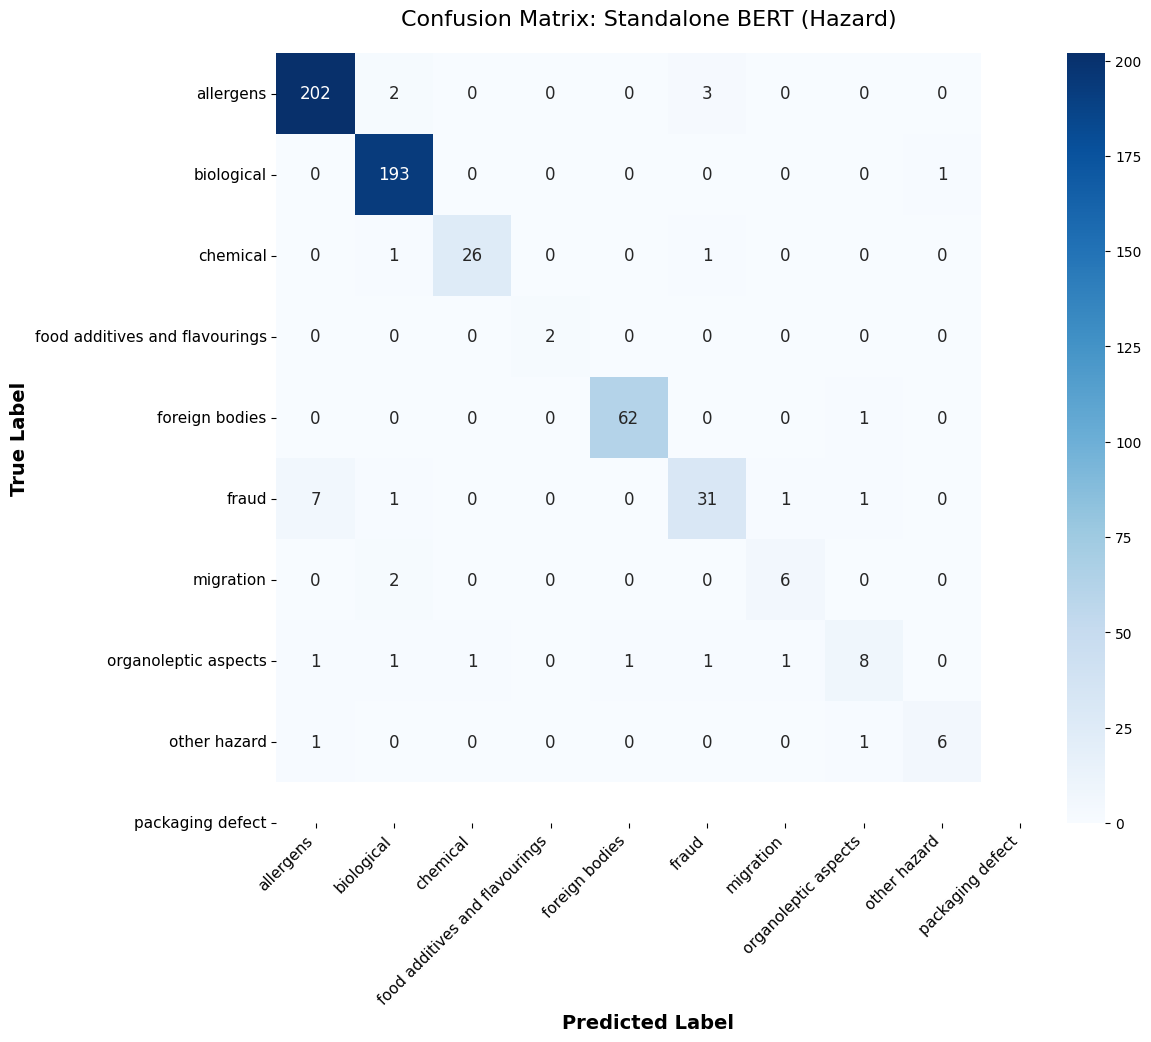

In [ ]:
post_processor.plot_hazard_confusion_matrix(preds_haz_val=preds_hazard_val)

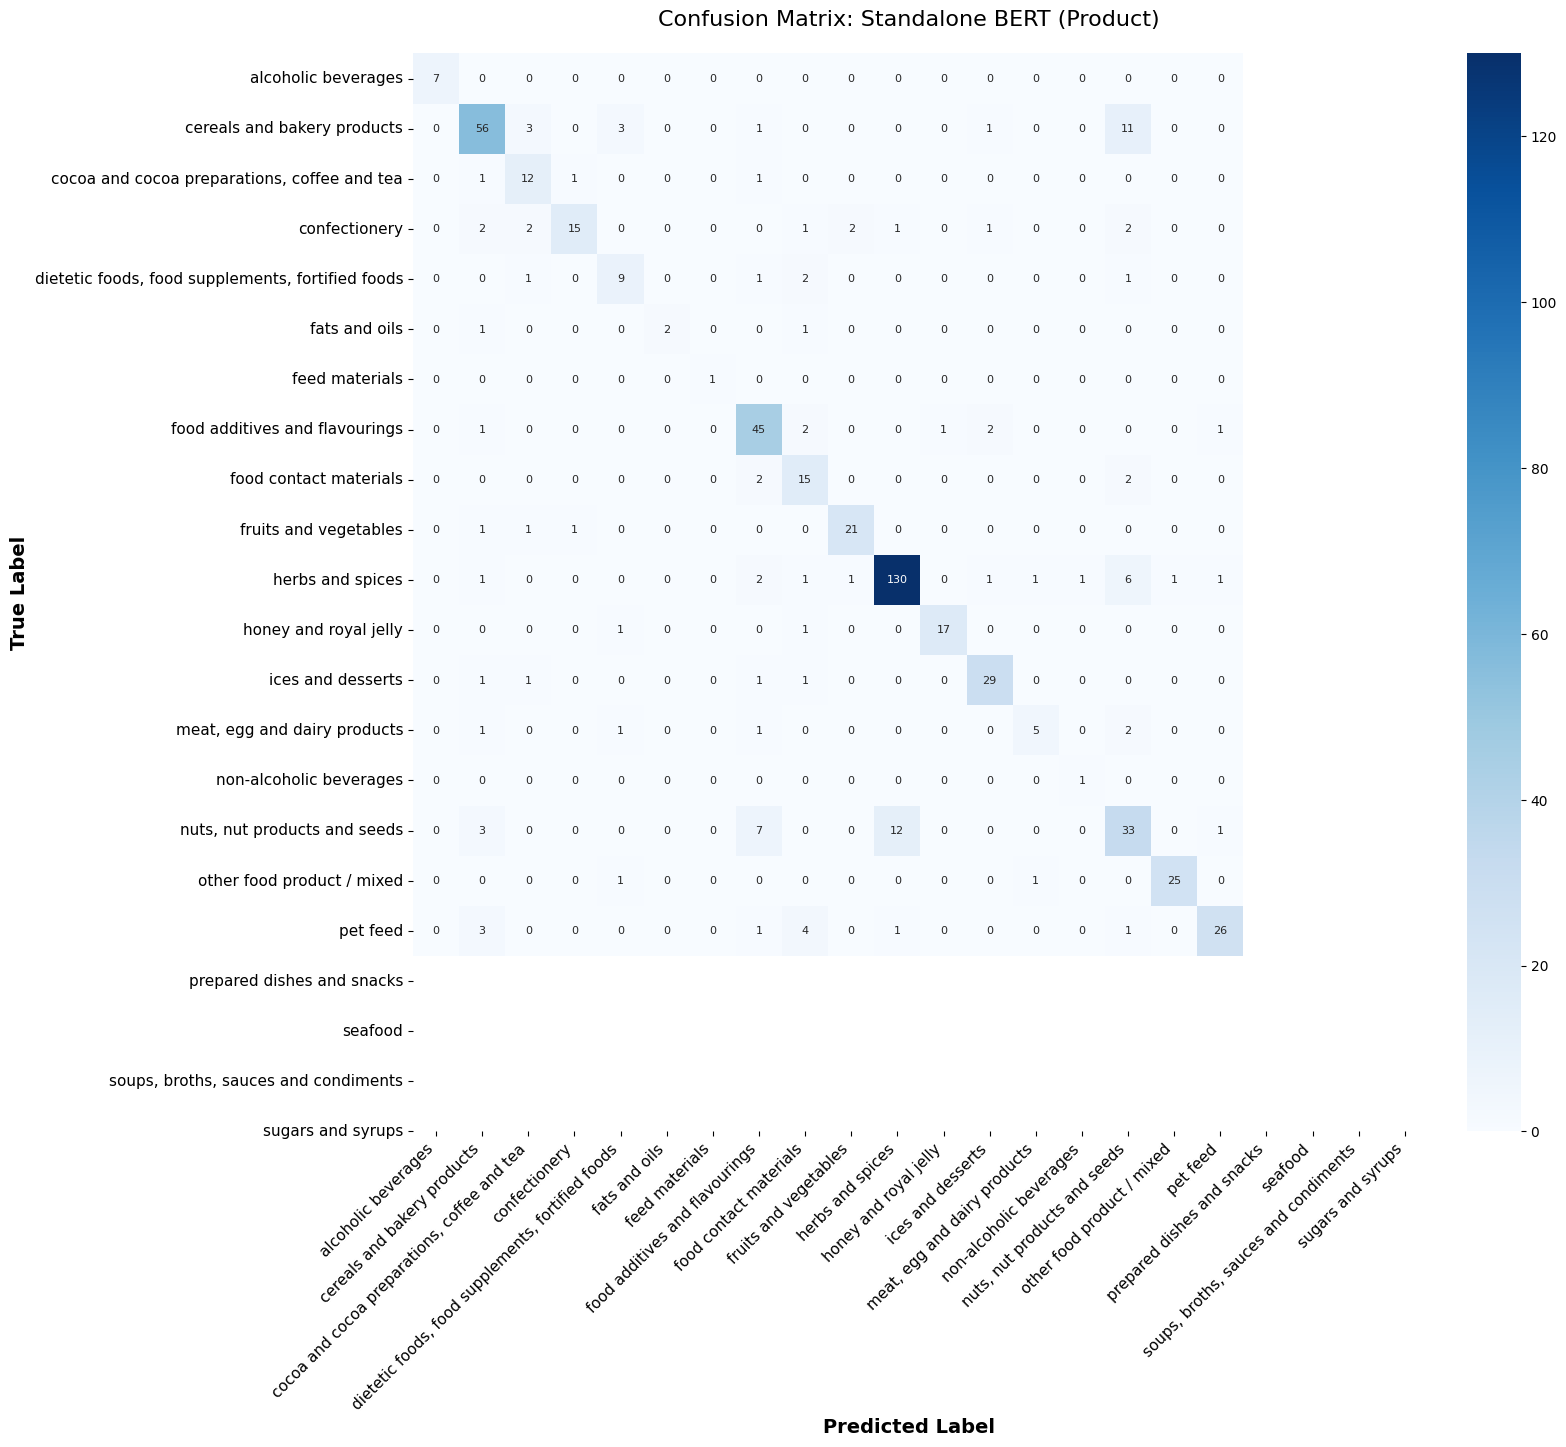

In [ ]:
post_processor.plot_product_confusion_matrix(preds_prod_val=preds_product_val)